# Filtros en GPU

Esta segunda sección demuestra cómo lograr un alto rendimiento en tareas de procesamiento de imágenes apoytándonos de GPUs y, en particular, de su ejecución con CUDA de NVIDIA. el script implementa filtros de imagen comunes dentro de Visión Computacional, escribiendo kernels de CUDA C++ personalizados directamente en Python, gracias a la funcionalidad de `RawKernel` de CuPy. 

El objetivo es demostrar como estos resultados superan en tiempos de ejecución a los encontrados por el procesamiento en CPU. 

### Descripción del Código

Aprovechando la paralelización de la arquitectura GPU, el script está preparado para aplicar nuestros tres kernels a cada imagen seleccionada: 

* **Kernels CUDA**: definimos la lógica para cada filtro a nivel de un solo hilo. Esto se compilan en tiempo de ejecución por CuPy. 
* **Funciones Auxiliares**: sdon las funciones de Python que se encargarn de mover los datos de la memoria dle sistema a la memoria de la GPU, i.e. de la RAM a la VRAM. Configura la ejecución del kernel y transifere los resultados de vuelta al equipo. 
* **Función Principal**: se gestiona la carga de la imagen original, se aplican los filtros, la medición temporal y la visualización. 

Se aporvecha la implementación en GPU para acelerar significativamente los resultados. Con apoyo de `cupy.RawKernel` podmeos escribir código CUDA optimizado para mejor control sobre el hardware. Además, cada filtro está diseño para usarse en múltiples hilos de la GPU, y permitir que así se trabajen en paralelo las operaciones realizadas por los filtros. Además, también podemos procesar imágenes en escala de grises o en RGB. 

Si trabajamos en RGB, cada filtro se aplica canal por canal. 

### Filtros Implementados

Implementamos los siguientes tres filtros clásicos de Visión Computacional:

* **Filtro de Media**: suaviza la imagen, reduciendo el ruido. Realiza una convolución con un kernel promediado, el tamaño del kernel se puede definir por el usuario. 
* **Magnitud del Gradiente**: utilizado para detectar bordes y áreas con cambios bruscos de intensidad. Calcula la diferencia entre píxeles en las direcciones X y Y, para aproximar las derivadas y luego calcular la magnitud dle vector gradiente reusltante. 
* **Filtro Laplaciano**: es un detecto de bordes de segundo orden, su uso común es el de resaltar detalles más finos. Aplica la convolución con el kernel Laplacinao estándar. 

In [ ]:
import cupy as cp
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt

# ===============================================================
# FUNCIONES AUXILIARES
# ===============================================================

def cargar_preparar_imagen(image_path, modo_color=False):
    flag = cv2.IMREAD_COLOR if modo_color else cv2.IMREAD_GRAYSCALE
    img = cv2.imread(image_path, flag)

    if img is None:
        raise FileNotFoundError(f"No se pudo cargar la imagen: {image_path}")

    img = img.astype(np.float32) / 255.0
    if modo_color:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img


# ===============================================================
# KERNELS CUDA
# ===============================================================

media_kernel = cp.RawKernel(r'''
extern "C" __global__
void filtro_media(const float* img, float* out, int w, int h, int k) {
    int x = blockDim.x * blockIdx.x + threadIdx.x;
    int y = blockDim.y * blockIdx.y + threadIdx.y;

    if (x >= w || y >= h) return;

    float sum = 0.0;
    int count = 0;
    int half = k / 2;

    for (int dy = -half; dy <= half; ++dy) {
        for (int dx = -half; dx <= half; ++dx) {
            int nx = x + dx;
            int ny = y + dy;
            if (nx >= 0 && nx < w && ny >= 0 && ny < h) {
                sum += img[ny * w + nx];
                count++;
            }
        }
    }
    out[y * w + x] = sum / count;
}
''', 'filtro_media')


gradiente_kernel = cp.RawKernel(r'''
extern "C" __global__
void gradiente_magnitud(const float* img, float* out, int w, int h) {
    int x = blockDim.x * blockIdx.x + threadIdx.x;
    int y = blockDim.y * blockIdx.y + threadIdx.y;

    if (x >= w || y >= h) return;

    float dx = 0.0f, dy = 0.0f;

    if (x < w - 1) dx = img[y * w + (x + 1)] - img[y * w + x];
    if (y < h - 1) dy = img[(y + 1) * w + x] - img[y * w + x];

    out[y * w + x] = sqrtf(dx * dx + dy * dy);
}
''', 'gradiente_magnitud')


laplaciano_kernel = cp.RawKernel(r'''
extern "C" __global__
void laplaciano(const float* img, float* out, int w, int h) {
    int x = blockDim.x * blockIdx.x + threadIdx.x;
    int y = blockDim.y * blockIdx.y + threadIdx.y;

    if (x >= w || y >= h) return;

    float c = img[y * w + x];
    float up = (y > 0) ? img[(y - 1) * w + x] : c;
    float down = (y < h - 1) ? img[(y + 1) * w + x] : c;
    float left = (x > 0) ? img[y * w + (x - 1)] : c;
    float right = (x < w - 1) ? img[y * w + (x + 1)] : c;

    out[y * w + x] = (up + down + left + right - 4.0f * c);
}
''', 'laplaciano')


# ===============================================================
# FUNCIONES DE FILTROS GPU
# ===============================================================

def aplicar_filtro_media_gpu(imagen, tamano_kernel=5):
    h, w = imagen.shape
    img_gpu = cp.asarray(imagen)
    out_gpu = cp.zeros_like(img_gpu)

    block = (16, 16)
    grid = ((w + block[0] - 1) // block[0],
            (h + block[1] - 1) // block[1])

    media_kernel(grid, block, (img_gpu, out_gpu, np.int32(w), np.int32(h), np.int32(tamano_kernel)))
    return cp.asnumpy(out_gpu)


def aplicar_gradiente_gpu(imagen):
    h, w = imagen.shape
    img_gpu = cp.asarray(imagen)
    out_gpu = cp.zeros_like(img_gpu)

    block = (16, 16)
    grid = ((w + block[0] - 1) // block[0],
            (h + block[1] - 1) // block[1])

    gradiente_kernel(grid, block, (img_gpu, out_gpu, np.int32(w), np.int32(h)))

    out = cp.asnumpy(out_gpu)
    return (out - out.min()) / (out.max() - out.min())


def aplicar_laplaciano_gpu(imagen):
    h, w = imagen.shape
    img_gpu = cp.asarray(imagen)
    out_gpu = cp.zeros_like(img_gpu)

    block = (16, 16)
    grid = ((w + block[0] - 1) // block[0],
            (h + block[1] - 1) // block[1])

    laplaciano_kernel(grid, block, (img_gpu, out_gpu, np.int32(w), np.int32(h)))
    return cp.asnumpy(out_gpu)


# ===============================================================
# FUNCIÓN PRINCIPAL GPU
# ===============================================================

def apply_filters_gpu(image_path, filter_sequence, modo_color=False, **kwargs):
    filtros = {
        'media': aplicar_filtro_media_gpu,
        'gradiente': aplicar_gradiente_gpu,
        'laplaciano': aplicar_laplaciano_gpu
    }

    img_original = cargar_preparar_imagen(image_path, modo_color=modo_color)

    resultados = {}
    tiempos = {}

    for f in filter_sequence:
        if f not in filtros:
            print(f" Filtro '{f}' no reconocido. Se omite.")
            continue

        print(f"-> Aplicando filtro (GPU): {f}")
        start = time.perf_counter()

        if f == 'media':
            k = kwargs.get('kernel_size', 5)
            if img_original.ndim == 3:
                out = np.stack([filtros[f](img_original[..., c], tamano_kernel=k) for c in range(3)], axis=-1)
            else:
                out = filtros[f](img_original, tamano_kernel=k)
        else:
            if img_original.ndim == 3:
                out = np.stack([filtros[f](img_original[..., c]) for c in range(3)], axis=-1)
            else:
                out = filtros[f](img_original)

        cp.cuda.Device(0).synchronize()  # Esperar a GPU
        end = time.perf_counter()
        resultados[f] = out
        tiempos[f] = end - start
        print(f"   Tiempo GPU: {tiempos[f]:.6f} s")

    return img_original, resultados, tiempos


# ===============================================================
# VISUALIZACIÓN
# ===============================================================

def mostrar_resultados(img_original, resultados, tiempos):
    filtros = list(resultados.keys())
    n = len(filtros)

    if n == 1:
        filas, cols = 1, 2
    elif n == 2:
        filas, cols = 1, 3
    else:
        filas, cols = 2, 2

    plt.figure(figsize=(14, 8))
    plt.subplot(filas, cols, 1)
    plt.imshow(img_original, cmap='gray' if img_original.ndim == 2 else None)
    plt.title("Imagen Original")
    plt.axis('off')

    for i, f in enumerate(filtros, start=2):
        plt.subplot(filas, cols, i)
        plt.imshow(resultados[f], cmap='gray' if resultados[f].ndim == 2 else None)
        plt.title(f"{f.capitalize()} ({tiempos[f]:.4f} s)")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

     # Gráfica de tiempos
    plt.figure(figsize=(6, 4))
    plt.bar(tiempos.keys(), tiempos.values(), color='skyblue')
    plt.title("Tiempos de ejecución por filtro")
    plt.ylabel("Segundos")
    plt.xlabel("Filtro")
    plt.show()

-> Aplicando filtro (GPU): media
   Tiempo GPU: 0.066993 s
-> Aplicando filtro (GPU): gradiente
   Tiempo GPU: 0.046345 s
-> Aplicando filtro (GPU): laplaciano
   Tiempo GPU: 0.030423 s


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


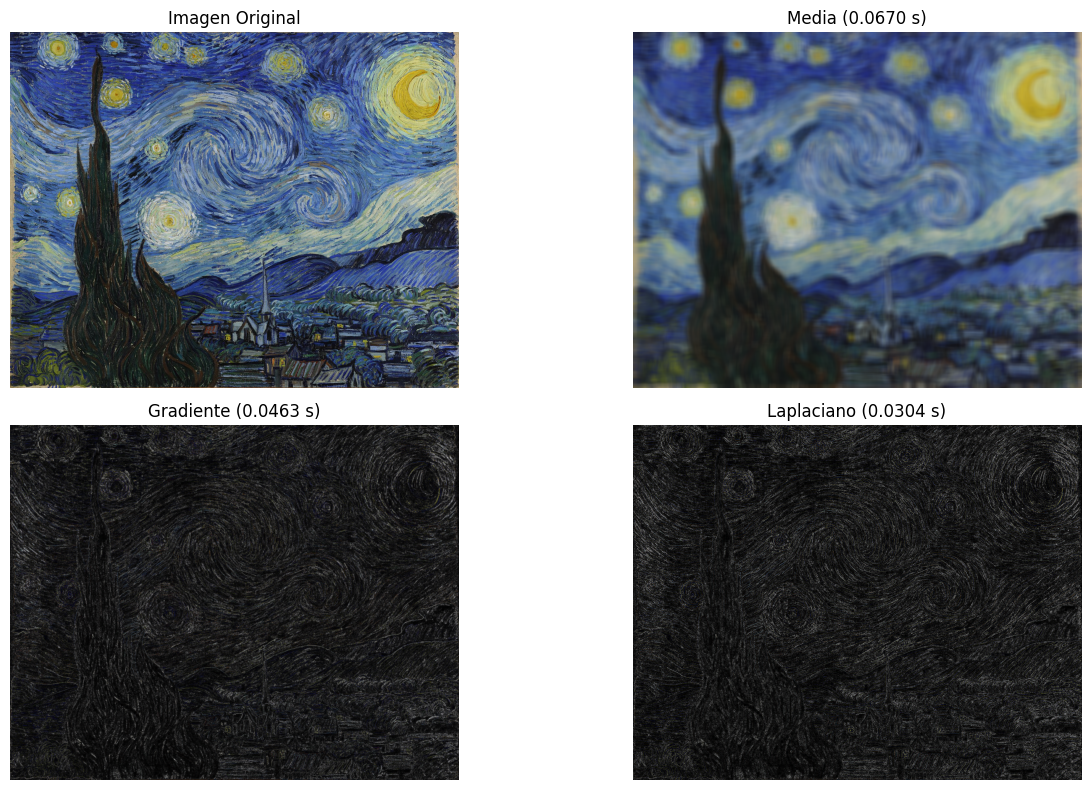

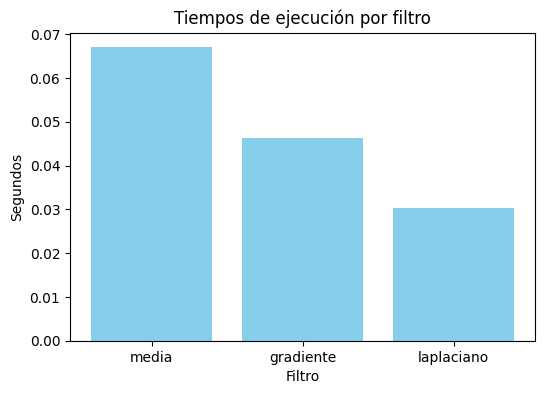

In [13]:
# ===============================================================
# MAIN
# ===============================================================

if __name__ == "__main__":
    FILENAME = "/home/cesar/Natural-Language-Processing-and-Computer-Vision/Visión-Computacional/Tarea-01-Filtros/imagenes/VanGogh.jpg"
    FILTROS_A_APLICAR = ['media', 'gradiente', 'laplaciano']
    HIPERPARAMETROS = {'kernel_size': 20}

    original, resultados, tiempos = apply_filters_gpu(
        image_path=FILENAME,
        filter_sequence=FILTROS_A_APLICAR,
        modo_color=True,
        **HIPERPARAMETROS
    )

    mostrar_resultados(original, resultados, tiempos)


-> Aplicando filtro (GPU): media
   Tiempo GPU: 0.097527 s
-> Aplicando filtro (GPU): gradiente
   Tiempo GPU: 0.055399 s
-> Aplicando filtro (GPU): laplaciano
   Tiempo GPU: 0.038947 s


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


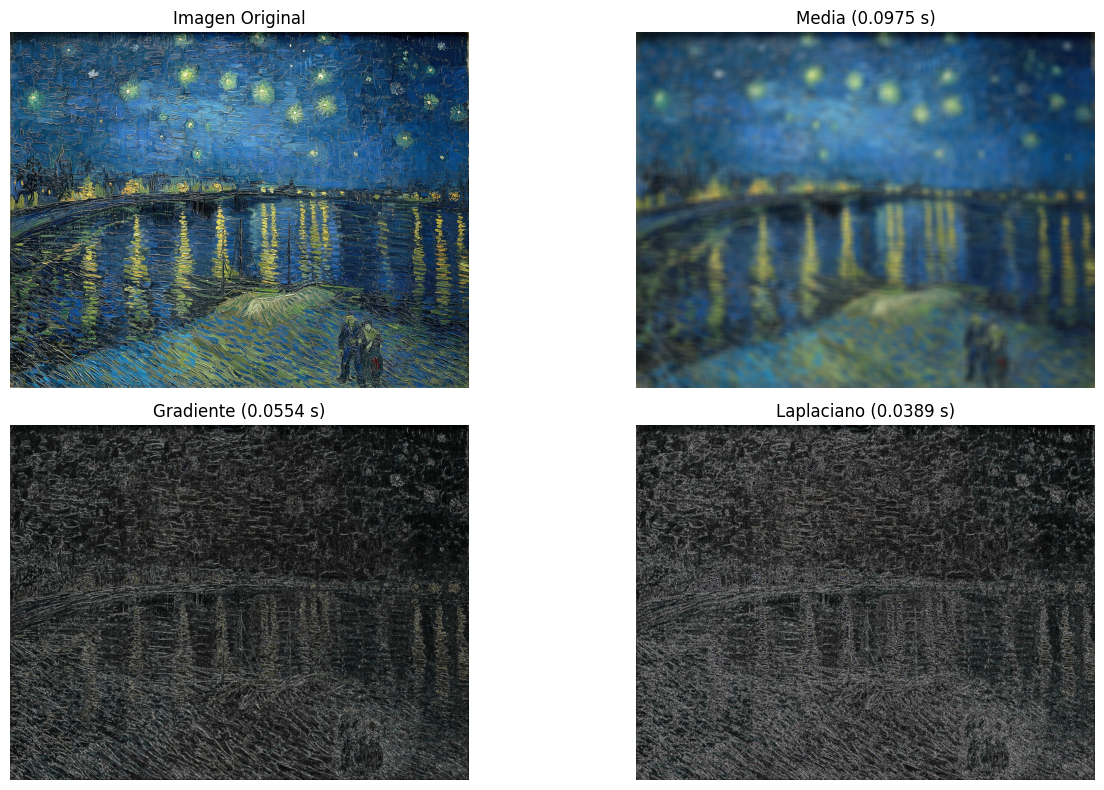

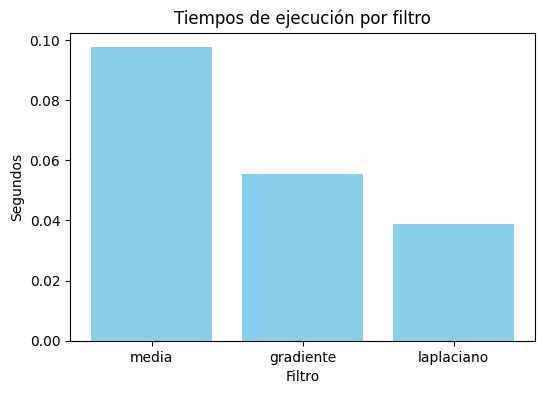

In [14]:
# ===============================================================
# MAIN
# ===============================================================

if __name__ == "__main__":
    FILENAME = "/home/cesar/Natural-Language-Processing-and-Computer-Vision/Visión-Computacional/Tarea-01-Filtros/imagenes/VanGogh2.jpg"
    FILTROS_A_APLICAR = ['media', 'gradiente', 'laplaciano']
    HIPERPARAMETROS = {'kernel_size': 20}

    original, resultados, tiempos = apply_filters_gpu(
        image_path=FILENAME,
        filter_sequence=FILTROS_A_APLICAR,
        modo_color=True,
        **HIPERPARAMETROS
    )

    mostrar_resultados(original, resultados, tiempos)

-> Aplicando filtro (GPU): media
   Tiempo GPU: 0.075588 s
-> Aplicando filtro (GPU): gradiente
   Tiempo GPU: 0.028943 s
-> Aplicando filtro (GPU): laplaciano
   Tiempo GPU: 0.022360 s


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


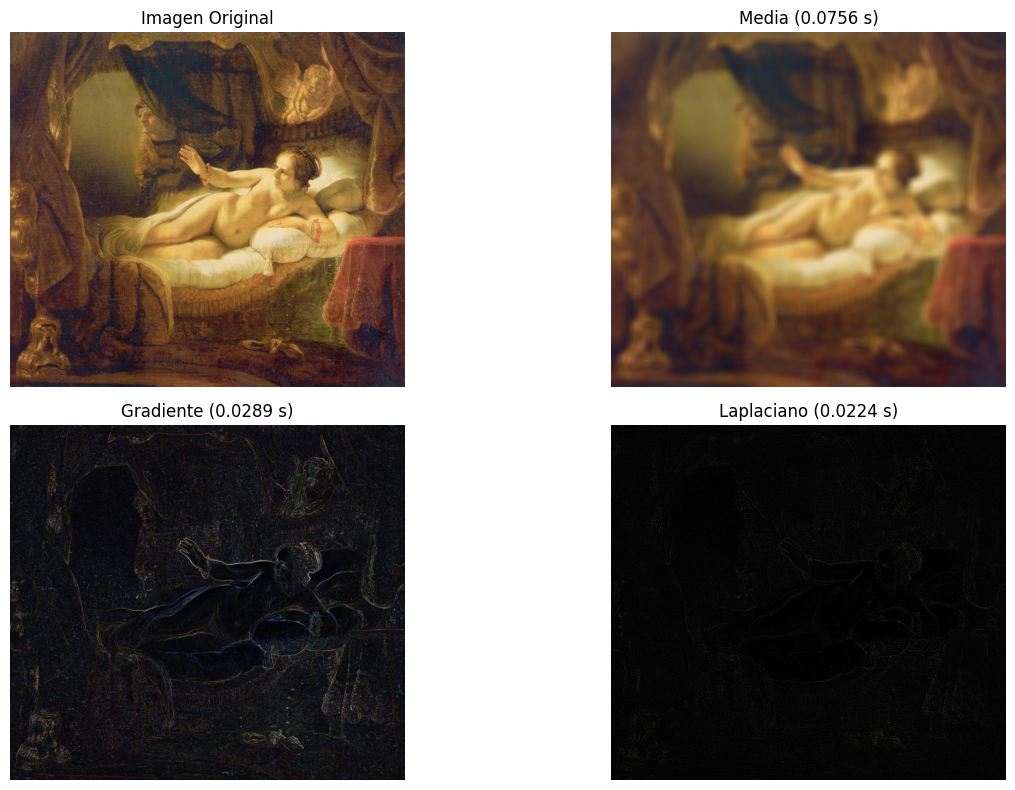

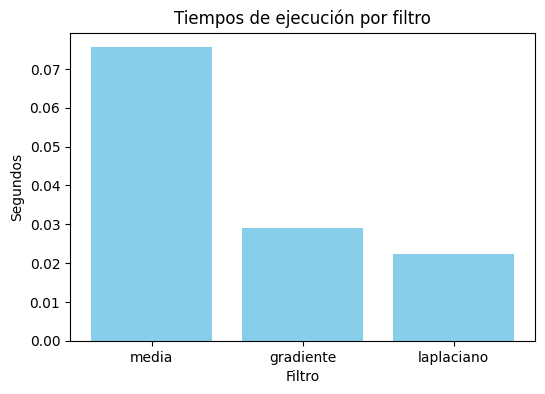

In [15]:
# ===============================================================
# MAIN
# ===============================================================

if __name__ == "__main__":
    FILENAME = "/home/cesar/Natural-Language-Processing-and-Computer-Vision/Visión-Computacional/Tarea-01-Filtros/imagenes/Danae.png"
    FILTROS_A_APLICAR = ['media', 'gradiente', 'laplaciano']
    HIPERPARAMETROS = {'kernel_size': 20}

    original, resultados, tiempos = apply_filters_gpu(
        image_path=FILENAME,
        filter_sequence=FILTROS_A_APLICAR,
        modo_color=True,
        **HIPERPARAMETROS
    )

    mostrar_resultados(original, resultados, tiempos)

-> Aplicando filtro (GPU): media
   Tiempo GPU: 0.105542 s
-> Aplicando filtro (GPU): gradiente
   Tiempo GPU: 0.051842 s
-> Aplicando filtro (GPU): laplaciano
   Tiempo GPU: 0.032647 s


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


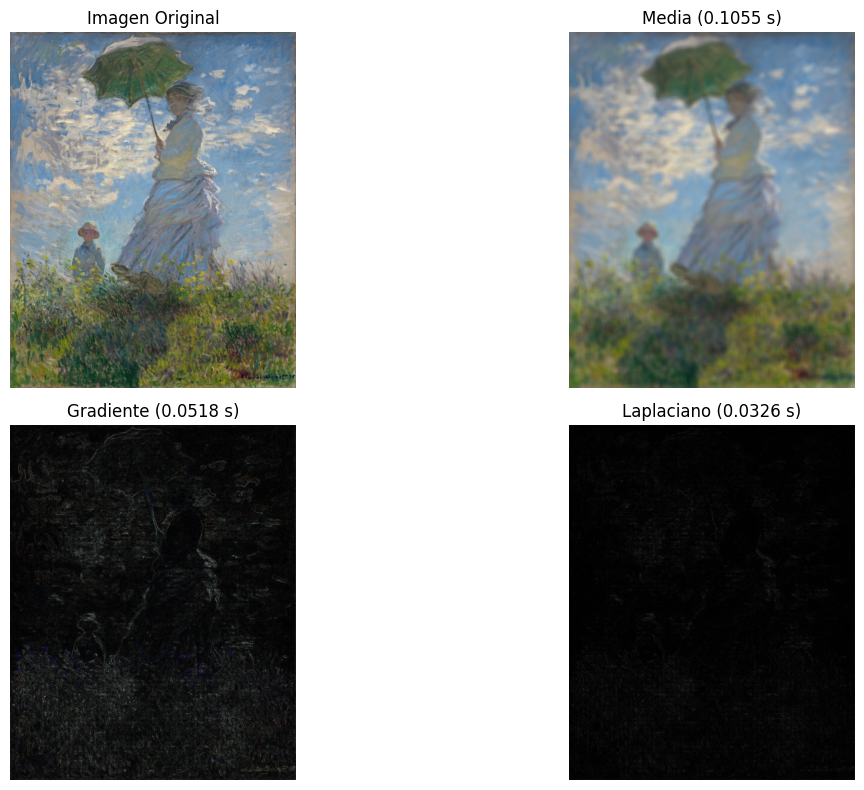

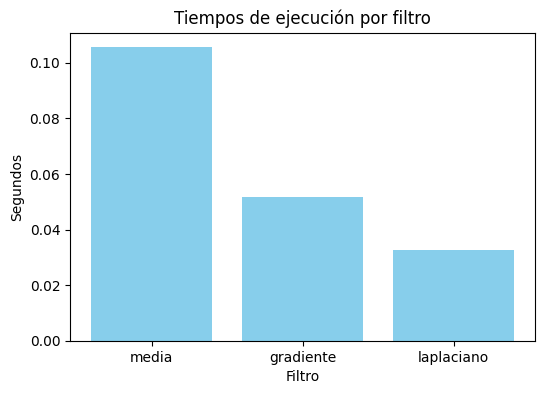

In [16]:
# ===============================================================
# MAIN
# ===============================================================

if __name__ == "__main__":
    FILENAME = "/home/cesar/Natural-Language-Processing-and-Computer-Vision/Visión-Computacional/Tarea-01-Filtros/imagenes/Monet.jpg"
    FILTROS_A_APLICAR = ['media', 'gradiente', 'laplaciano']
    HIPERPARAMETROS = {'kernel_size': 20}

    original, resultados, tiempos = apply_filters_gpu(
        image_path=FILENAME,
        filter_sequence=FILTROS_A_APLICAR,
        modo_color=True,
        **HIPERPARAMETROS
    )

    mostrar_resultados(original, resultados, tiempos)

-> Aplicando filtro (GPU): media
   Tiempo GPU: 0.096238 s
-> Aplicando filtro (GPU): gradiente
   Tiempo GPU: 0.047391 s
-> Aplicando filtro (GPU): laplaciano
   Tiempo GPU: 0.022010 s


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


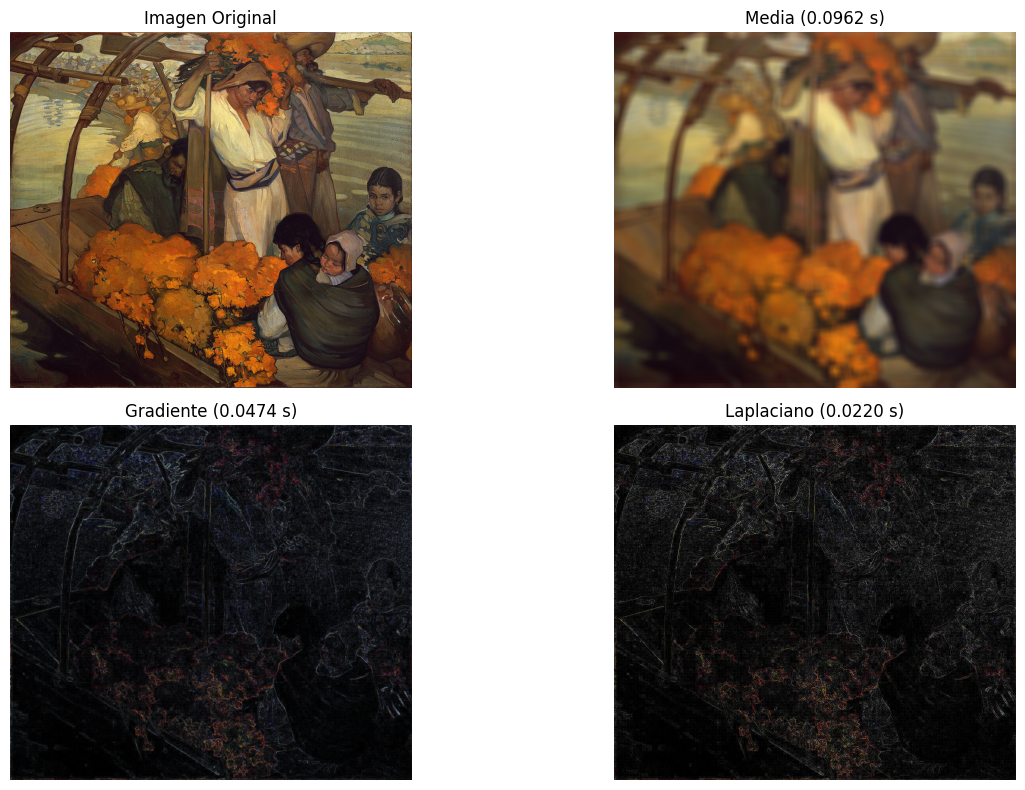

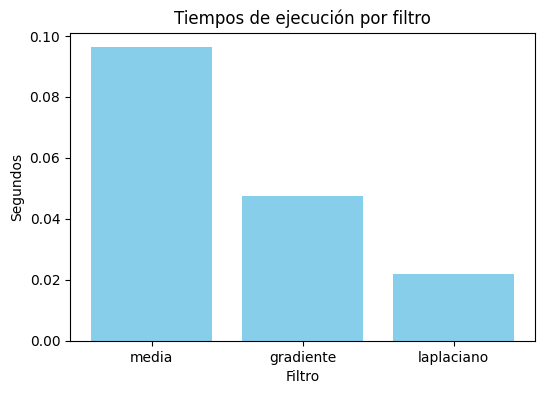

In [17]:
# ===============================================================
# MAIN
# ===============================================================

if __name__ == "__main__":
    FILENAME = "/home/cesar/Natural-Language-Processing-and-Computer-Vision/Visión-Computacional/Tarea-01-Filtros/imagenes/LaOfrenda_Saturnino.jpg"
    FILTROS_A_APLICAR = ['media', 'gradiente', 'laplaciano']
    HIPERPARAMETROS = {'kernel_size': 20}

    original, resultados, tiempos = apply_filters_gpu(
        image_path=FILENAME,
        filter_sequence=FILTROS_A_APLICAR,
        modo_color=True,
        **HIPERPARAMETROS
    )

    mostrar_resultados(original, resultados, tiempos)